In [1]:
# libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline
import random
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.offsetbox as offsetbox # for text box with position control
import pickle
import seaborn as sns

In [2]:
mochi_results = pd.read_csv("mochi/epistasis_summary.txt",
                            sep = "\t")
mochi_results["percent_raw"] = 100* (mochi_results["number_interactions_raw"] / mochi_results["total_possible_combinations"])
mochi_results["percent_1d"] = 100* (mochi_results["number_interactions_1d"] / mochi_results["total_possible_combinations"])
mochi_results["percent_common"] = 100* (mochi_results["number_preserved_interactions_1d"] / mochi_results["total_possible_combinations"])

mochi_results["normalised_raw"] = 100* (mochi_results["number_interactions_raw"] / mochi_results["number_interactions_raw"])
mochi_results["normalised_1d"] = 100* (mochi_results["number_interactions_1d"] / mochi_results["number_interactions_raw"])
mochi_results["normalised_common"] = 100* (mochi_results["number_preserved_interactions_1d"] / mochi_results["number_interactions_raw"])

mochi_results

,n,total_possible_combinations,number_interactions_raw,number_interactions_1d,number_preserved_interactions_1d,percent_raw,percent_1d,percent_common,normalised_raw,normalised_1d,normalised_common
0,1,14,13,1,1,92.857143,7.142857,7.142857,100.0,7.692308,7.692308
1,2,87,30,26,25,34.482759,29.885057,28.735632,100.0,86.666667,83.333333
2,3,316,12,12,11,3.797468,3.797468,3.481013,100.0,100.000000,91.666667
3,4,743,32,33,32,4.306864,4.441454,4.306864,100.0,103.125000,100.000000
4,5,1182,29,29,29,2.453469,2.453469,2.453469,100.0,100.000000,100.000000
5,6,1269,25,25,25,1.970055,1.970055,1.970055,100.0,100.000000,100.000000
6,7,876,22,22,22,2.511416,2.511416,2.511416,100.0,100.000000,100.000000
7,8,355,7,7,7,1.971831,1.971831,1.971831,100.0,100.000000,100.000000
8,9,59,2,2,2,3.389831,3.389831,3.389831,100.0,100.000000,100.000000
9,10,2,0,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN


In [3]:
y1 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["percent_raw"][i]):
        break
    y1.append(mochi_results["percent_raw"][i])

y2 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["percent_1d"][i]):
        break
    y2.append(mochi_results["percent_1d"][i])

y3 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["percent_common"][i]):
        break
    y3.append(mochi_results["percent_common"][i])

x = np.array([i for i in range(len(y1))])

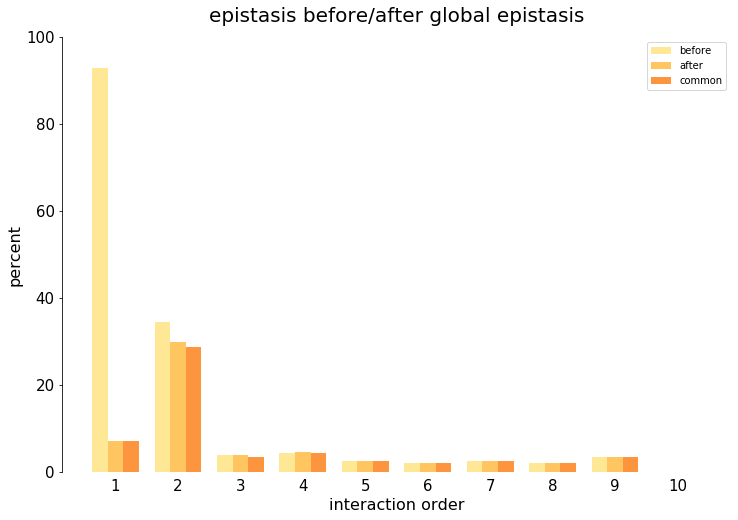

In [4]:
from matplotlib import cm
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['axes.spines.left'] = True
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.bottom'] = False
matplotlib.rcParams['xtick.bottom'] = False


width = 0.25

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.bar(x,
       y1,
       width = width,
       label = "before",
       color = cm.YlOrRd(np.linspace(0,1,20))[3])
ax.bar(x+width,
       y2,
       width = width,
       label = "after",
       color = cm.YlOrRd(np.linspace(0,1,20))[6])
ax.bar(x+width+width,
       y3,
       width = width,
       label = "common",
       color = cm.YlOrRd(np.linspace(0,1,20))[9])


# x axis
ax.set_xticks(np.arange(len(y1))+width)
ax.set_xticklabels(labels = [ str(i+1) for i in range(len(y1)) ])



ax.set_ylabel("percent",
              fontsize = 16)

ax.set_xlabel("interaction order",
              fontsize = 16)

# tick font size
ax.tick_params(axis='both', which='major', labelsize=15)

ax.legend()

# title
ax.set_title("epistasis before/after global epistasis",
             fontsize = 20,
             pad = 15)

ax.set_ylim([0,100])

plt.savefig("010_Epistasis_Before_After_Common_Percent.pdf", transparent=True)

In [5]:
y1 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["normalised_raw"][i]):
        break
    y1.append(mochi_results["normalised_raw"][i])

y2 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["normalised_1d"][i]):
        break
    y2.append(mochi_results["normalised_1d"][i])

y3 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["normalised_common"][i]):
        break
    y3.append(mochi_results["normalised_common"][i])

x = np.array([i for i in range(len(y1))])

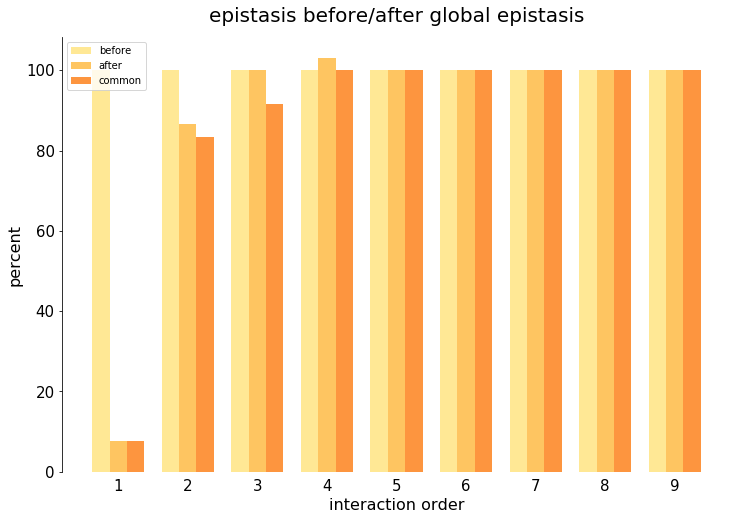

In [6]:
from matplotlib import cm
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['axes.spines.left'] = True
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.bottom'] = False
matplotlib.rcParams['xtick.bottom'] = False


width = 0.25

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.bar(x,
       y1,
       width = width,
       label = "before",
       color = cm.YlOrRd(np.linspace(0,1,20))[3])
ax.bar(x+width,
       y2,
       width = width,
       label = "after",
       color = cm.YlOrRd(np.linspace(0,1,20))[6])
ax.bar(x+width+width,
       y3,
       width = width,
       label = "common",
       color = cm.YlOrRd(np.linspace(0,1,20))[9])


# x axis
ax.set_xticks(np.arange(len(y1))+width)
ax.set_xticklabels(labels = [ str(i+1) for i in range(len(y1)) ])



ax.set_ylabel("percent",
              fontsize = 16)

ax.set_xlabel("interaction order",
              fontsize = 16)

# tick font size
ax.tick_params(axis='both', which='major', labelsize=15)

ax.legend()

# title
ax.set_title("epistasis before/after global epistasis",
             fontsize = 20,
             pad = 15)

#ax.set_ylim([0,100])

plt.savefig("010_Epistasis_Before_After_Common_Normalised.pdf", transparent=True)